# Evaluation results visualization

**Requires:** `pip install pandas matplotlib`

- Group by `story_prompt`; average multiple rows per prompt before macro-averages across prompts.
- For flag ablations, fix `specialist_model_variant_tag` (e.g. `BackgroundMellow_baseline_tango2`) so specialist swaps do not confound flag effects.

In [17]:
from __future__ import annotations

import os
from dataclasses import dataclass
from typing import Any, Dict, Iterable, List, Literal, Mapping, Optional, Tuple

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pathlib import Path


## Constants

In [18]:
BOOL_FLAG_COLUMNS: Tuple[str, ...] = (
    "flag_fill_coverage_by_llm",
    "flag_use_dsp",
    "flag_use_movie_bgms",
    "flag_use_narrator",
    "flag_use_llm_to_predict_align",
    "flag_use_dsp_to_predict_align",
    "flag_use_avg_llm_and_dsp_to_predict_align",
    "flag_use_dl_based_llm_and_dsp_alignment_predictor",
)

DEFAULT_OBJECTIVE: Dict[str, Literal["maximize", "minimize"]] = {
    "clap_score": "maximize",
    "audio_richness_spectral_flatness": "maximize",
    "audio_richness_spectral_entropy": "maximize",
    "noise_floor_db": "maximize",
    "audio_onsets": "maximize",
    "yt_coverage_score": "maximize",
    "yt_sync_score": "maximize",
    "yt_coverage_and_sync_coverage_score": "maximize",
    "yt_coverage_and_sync_sync_score": "maximize",
    "cinematic_dynamic_range_db": "maximize",
    "cinematic_crest_factor": "maximize",
    "cinematic_spectral_flatness": "maximize",
    "cinematic_spectral_entropy": "maximize",
    "cinematic_spectral_centroid_hz": "maximize",
    "spectral_kl_divergence": "minimize",
    "fad_score": "minimize",
    "total_seconds": "minimize",
    "pipeline_total_seconds": "minimize",
    "evaluation_seconds": "minimize",
}

## Load and clean CSV

In [19]:
def _parse_bool_series(s: pd.Series) -> pd.Series:
    if s.dtype == bool:
        return s
    up = s.astype(str).str.strip().str.upper()
    return up.map({"TRUE": True, "FALSE": False, "1": True, "0": False}).fillna(False)


def load_results_csv(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path, low_memory=False)
    for col in BOOL_FLAG_COLUMNS:
        if col in df.columns:
            df[col] = _parse_bool_series(df[col])
    return df


def clean_results_df(
    df: pd.DataFrame,
    *,
    drop_empty_experiment_tag: bool = True,
    exclude_errors: bool = True,
) -> pd.DataFrame:
    out = df.copy()
    if drop_empty_experiment_tag and "experiment_tag" in out.columns:
        out = out[out["experiment_tag"].notna() & (out["experiment_tag"].astype(str).str.strip() != "")]
    if exclude_errors and "error" in out.columns:
        err = out["error"]
        mask = err.isna() | (err.astype(str).str.strip() == "")
        out = out[mask]
    return out

# Mix results

In [20]:
def _norm_story(s: Any) -> str:
    if s is None or (isinstance(s, float) and pd.isna(s)):
        return ""
    return str(s).strip()


def mix_results(
    final_results_path: str,
    tango_results_path: str,
    audioldm_results_path: str,
    *,
    include_final_rows: bool = True,
    output_path: str | None = None,
) -> pd.DataFrame:
    """
    Merge Tango2 / AudioLDM2 BackgroundMellow_baseline CSVs into the ``final_results`` column schema.

    For each BackgroundMellow_baseline row, finds the first row in ``final_results`` with the same
    ``story_prompt`` (stripped) and copies dataset / config columns from it. Pipeline
    timing fields, YouTube alignment metrics, and cue JSON fields are left blank;
    metrics and ``total_seconds`` come from the BackgroundMellow_baseline file. ``experiment_tag`` is
    set to ``tango2`` or ``AudioLDM2``; ``specialist_model_variant_tag`` matches for plots.

    Parameters
    ----------
    final_results_path
        Full pipeline results CSV (schema superset).
    tango_results_path, audioldm_results_path
        Outputs from ``BackgroundMellow_baseline_models_evaluation.py`` (subset of metric columns).
    include_final_rows
        If True, returned frame is ``final_results`` rows then BackgroundMellow_baseline rows; if False,
        only the synthesized BackgroundMellow_baseline rows.
    output_path
        If set, write the result with ``to_csv(..., index=False)``.
    """
    final_df = pd.read_csv(final_results_path, low_memory=False)
    for col in BOOL_FLAG_COLUMNS:
        if col in final_df.columns:
            final_df[col] = _parse_bool_series(final_df[col])

    cols = list(final_df.columns)
    meta_src = final_df.copy()
    meta_src["_sp"] = meta_src["story_prompt"].map(_norm_story)
    meta_by_prompt = meta_src.drop_duplicates(subset=["_sp"], keep="first").set_index("_sp")

    pipeline_blank = {
        "cue_decider_seconds": pd.NA,
        "initial_audio_generation_seconds": pd.NA,
        "missing_fill_seconds": pd.NA,
        "superimpose_seconds": pd.NA,
        "audio_to_base64_seconds": pd.NA,
        "pipeline_total_seconds": pd.NA,
        "evaluation_seconds": pd.NA,
    }
    yt_blank = {
        "yt_coverage_score": pd.NA,
        "yt_sync_score": pd.NA,
        "yt_coverage_and_sync_coverage_score": pd.NA,
        "yt_coverage_and_sync_sync_score": pd.NA,
    }
    json_blank = {
        "llm_suggested_cues_json": pd.NA,
        "final_superimposed_cues_json": pd.NA,
    }

    BackgroundMellow_baseline_metric_cols = [
        "total_seconds",
        "clap_score",
        "audio_richness_spectral_flatness",
        "audio_richness_spectral_entropy",
        "noise_floor_db",
        "audio_onsets",
        "cinematic_dynamic_range_db",
        "cinematic_crest_factor",
        "cinematic_spectral_flatness",
        "cinematic_spectral_entropy",
        "cinematic_spectral_centroid_hz",
        "spectral_kl_divergence",
        "fad_score",
        "error",
    ]
    optional_BackgroundMellow_baseline = ("audio_wav_path", "audio_export_error")

    def _one_BackgroundMellow_baseline_block(
        BackgroundMellow_baseline_df: pd.DataFrame,
        *,
        experiment_tag: str,
        specialist_tag: str,
    ) -> pd.DataFrame:
        rows: List[Dict[str, Any]] = []
        for _, br in BackgroundMellow_baseline_df.iterrows():
            key = _norm_story(br.get("story_prompt"))
            out: Dict[str, Any] = {c: pd.NA for c in cols}

            if key and key in meta_by_prompt.index:
                mr = meta_by_prompt.loc[key]
                for c in cols:
                    if c in mr.index:
                        out[c] = mr[c]

            out["story_prompt"] = br.get("story_prompt", pd.NA)
            out["experiment_tag"] = experiment_tag
            out["specialist_model_variant_tag"] = specialist_tag
            out["run_type"] = "BackgroundMellow_baseline_model"

            for k, v in pipeline_blank.items():
                if k in out:
                    out[k] = v
            for k, v in yt_blank.items():
                if k in out:
                    out[k] = v
            for k, v in json_blank.items():
                if k in out:
                    out[k] = v

            for m in BackgroundMellow_baseline_metric_cols:
                if m in cols and m in br.index:
                    out[m] = br[m]
            for m in optional_BackgroundMellow_baseline:
                if m in cols and m in br.index and pd.notna(br[m]) and str(br[m]).strip() != "":
                    out[m] = br[m]

            rows.append(out)
        return pd.DataFrame(rows, columns=cols)

    tango_df = pd.read_csv(tango_results_path, low_memory=False)
    audioldm_df = pd.read_csv(audioldm_results_path, low_memory=False)

    merged_tango = _one_BackgroundMellow_baseline_block(
        tango_df,
        experiment_tag="tango2",
        specialist_tag="tango2",
    )
    merged_ldm = _one_BackgroundMellow_baseline_block(
        audioldm_df,
        experiment_tag="AudioLDM2",
        specialist_tag="audioldm2",
    )

    if include_final_rows:
        out_df = pd.concat([final_df, merged_tango, merged_ldm], ignore_index=True)
    else:
        out_df = pd.concat([merged_tango, merged_ldm], ignore_index=True)

    if output_path:
        out_path = Path(output_path)
        out_path.parent.mkdir(parents=True, exist_ok=True)
        out_df.to_csv(out_path, index=False)

    return out_df


# Example (uncomment): cwd should be backend/Evaluation so ./Results/... resolves.
# _nb_results = Path.cwd() / "Results"
# if all((_nb_results / n).exists() for n in ("final_results.csv", "tango2_results.csv", "audioldm2_results.csv")):
#     df_mixed = mix_results(
#         str(_nb_results / "final_results.csv"),
#         str(_nb_results / "tango2_results.csv"),
#         str(_nb_results / "audioldm2_results.csv"),
#         output_path=str(_nb_results / "mixed_results.csv"),
#     )

## Configuration: infer, filter, objective


In [21]:
def infer_BackgroundMellow_baseline_config(df: pd.DataFrame) -> Dict[str, Any]:
    """Defaults from BackgroundMellow_baseline experiment + BackgroundMellow_baseline_tango2 specialist."""
    sub = df[
        (df["experiment_tag"].astype(str) == "BackgroundMellow_baseline")
        & (df["specialist_model_variant_tag"].astype(str) == "BackgroundMellow_baseline_tango2")
    ]
    if sub.empty:
        sub = df[df["experiment_tag"].astype(str) == "BackgroundMellow_baseline"]
    if sub.empty:
        raise ValueError("No BackgroundMellow_baseline rows found to infer default configuration.")
    row = sub.iloc[0]
    cfg: Dict[str, Any] = {}
    for c in BOOL_FLAG_COLUMNS:
        if c in row.index:
            cfg[c] = bool(row[c])
    for c in ("decide_audio_model_name", "specialist_model_variant_tag"):
        if c in row.index and pd.notna(row[c]):
            cfg[c] = str(row[c])
    return cfg


def filter_by_configuration(df: pd.DataFrame, config: Mapping[str, Any]) -> pd.DataFrame:
    out = df
    for key, val in config.items():
        if key not in out.columns:
            raise KeyError(f"Unknown column in config: {key}")
        if key in BOOL_FLAG_COLUMNS:
            out = out[out[key] == bool(val)]
        else:
            out = out[out[key].astype(str) == str(val)]
    return out


def resolve_objective(
    metric_col: str, objective: Optional[Literal["maximize", "minimize"]]
) -> Literal["maximize", "minimize"]:
    if objective is not None:
        return objective
    if metric_col in DEFAULT_OBJECTIVE:
        return DEFAULT_OBJECTIVE[metric_col]
    return "maximize"


In [22]:
@dataclass
class ConfigurationPlotInsights:
    metric_col: str
    n_prompts: int
    mean_over_prompts: float
    best_prompt: str
    best_value: float
    worst_prompt: str
    worst_value: float
    objective: str


## Plot: one configuration (per prompt)


In [23]:
def plot_metric_for_configuration(
    df: pd.DataFrame,
    metric_col: str,
    configuration: Optional[Mapping[str, Any]] = None,
    *,
    output_path: str,
    aggregate_how: Literal["mean"] = "mean",
    objective: Optional[Literal["maximize", "minimize"]] = None,
    exclude_errors: bool = True,
    prompt_label_max_len: int = 56,
    dpi: int = 150,
    save_pdf: bool = False,
) -> Tuple[pd.DataFrame, ConfigurationPlotInsights]:
    """
    Filter rows to ``configuration`` (defaults merged from infer_BackgroundMellow_baseline_config),
    aggregate metric per story_prompt, plot horizontal bars, save figure.
    Returns (per_prompt DataFrame, insights).
    """
    obj = resolve_objective(metric_col, objective)
    work = clean_results_df(df, exclude_errors=exclude_errors) if exclude_errors else df.copy()

    cfg: Dict[str, Any] = dict(infer_BackgroundMellow_baseline_config(work))
    if configuration:
        cfg.update(dict(configuration))

    filt = filter_by_configuration(work, cfg)
    if metric_col not in filt.columns:
        raise KeyError(f"Unknown metric column: {metric_col}")

    filt = filt.assign(**{metric_col: pd.to_numeric(filt[metric_col], errors="coerce")})
    filt = filt[filt[metric_col].notna()]
    if filt.empty:
        raise ValueError("No rows left after filtering for configuration and valid metric.")

    if aggregate_how == "mean":
        g = filt.groupby("story_prompt", as_index=False)[metric_col].mean()
    else:
        raise ValueError(f"Unsupported aggregate_how: {aggregate_how}")

    g = g.sort_values(metric_col, ascending=(obj == "minimize"))
    prompts = g["story_prompt"].astype(str).tolist()
    values = g[metric_col].astype(float).tolist()

    def short_label(p: str, i: int) -> str:
        s = p if len(p) <= prompt_label_max_len else p[: prompt_label_max_len - 1] + "…"
        return f"{i + 1}. {s}"

    labels = [short_label(p, i) for i, p in enumerate(prompts)]
    fig_h = max(6.0, 0.22 * len(labels))
    fig, ax = plt.subplots(figsize=(10, fig_h))
    ax.barh(range(len(labels)), values, color="steelblue")
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel(metric_col)
    ax.set_title(f"{metric_col} per story_prompt\nconfig={cfg}")
    ax.invert_yaxis()
    fig.tight_layout()
    d = os.path.dirname(os.path.abspath(output_path))
    if d:
        os.makedirs(d, exist_ok=True)
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight")
    if save_pdf:
        fig.savefig(os.path.splitext(output_path)[0] + ".pdf", bbox_inches="tight")
    plt.close(fig)

    mean_v = float(sum(values) / len(values)) if values else float("nan")
    if obj == "maximize":
        bi = max(range(len(values)), key=lambda i: values[i])
        wi = min(range(len(values)), key=lambda i: values[i])
    else:
        bi = min(range(len(values)), key=lambda i: values[i])
        wi = max(range(len(values)), key=lambda i: values[i])

    insights = ConfigurationPlotInsights(
        metric_col=metric_col,
        n_prompts=len(values),
        mean_over_prompts=mean_v,
        best_prompt=prompts[bi],
        best_value=float(values[bi]),
        worst_prompt=prompts[wi],
        worst_value=float(values[wi]),
        objective=obj,
    )
    print(
        f"[{metric_col}] mean_over_prompts={insights.mean_over_prompts:.6g} "
        f"best_prompt (truncated)={insights.best_prompt[:prompt_label_max_len]!r} "
        f"best_value={insights.best_value:.6g} objective={obj}"
    )
    return g.rename(columns={metric_col: f"mean_{metric_col}"}), insights


## Helpers for ablation comparison


In [24]:

def _per_prompt_means_for_slice(
    slice_df: pd.DataFrame,
    metric_col: str,
) -> pd.Series:
    s = pd.to_numeric(slice_df[metric_col], errors="coerce")
    tmp = slice_df.assign(_m=s)
    tmp = tmp[tmp["_m"].notna()]
    if tmp.empty:
        return pd.Series(dtype=float)
    return tmp.groupby("story_prompt")["_m"].mean()

In [25]:
def _ordered_experiment_tags(tags: Iterable[str]) -> List[str]:
    seen = set()
    ordered: List[str] = []
    for t in tags:
        if t and t not in seen:
            seen.add(t)
            ordered.append(t)

    def sort_key(t: str) -> Tuple[int, str]:
        if t == "BackgroundMellow_baseline":
            return (0, t)
        if t.startswith("decide_model_"):
            return (1, t)
        if t.startswith("toggle_"):
            return (2, t)
        return (3, t)

    return sorted(ordered, key=sort_key)


In [26]:
@dataclass
class AblationRow:
    label: str
    mean_over_prompts: float
    best_single_prompt_value: float
    n_prompts: int


In [27]:
def compare_ablations_for_metric(
    df: pd.DataFrame,
    metric_col: str,
    *,
    objective: Optional[Literal["maximize", "minimize"]] = None,
    specialist_model_variant_tag: str = "BackgroundMellow_baseline_tango2",
    output_dir: str,
    include_decide_model: bool = True,
    include_specialist_ablations: bool = False,
    exclude_errors: bool = True,
    dpi: int = 150,
) -> Tuple[pd.DataFrame, str]:
    """
    For each experiment_tag (optionally plus specialist-only bars), compute macro mean
    across prompts and best single-prompt mean; save two bar plots and a text report.
    Returns (summary DataFrame, report text).
    """
    obj = resolve_objective(metric_col, objective)
    work = clean_results_df(df, exclude_errors=exclude_errors) if exclude_errors else df.copy()
    if metric_col not in work.columns:
        raise KeyError(f"Unknown metric column: {metric_col}")

    os.makedirs(output_dir, exist_ok=True)

    rows_out: List[AblationRow] = []

    tag_series = work["experiment_tag"].astype(str)
    all_tags = _ordered_experiment_tags(tag_series.unique())

    def process_tag(ex_tag: str, label: Optional[str] = None) -> None:
        lab = label or ex_tag
        sub = work[
            (tag_series == ex_tag) & (work["specialist_model_variant_tag"].astype(str) == specialist_model_variant_tag)
        ]
        pm = _per_prompt_means_for_slice(sub, metric_col)
        if pm.empty:
            rows_out.append(
                AblationRow(label=lab, mean_over_prompts=float("nan"), best_single_prompt_value=float("nan"), n_prompts=0)
            )
            return
        mean_v = float(pm.mean())
        if obj == "maximize":
            best_v = float(pm.max())
        else:
            best_v = float(pm.min())
        rows_out.append(
            AblationRow(label=lab, mean_over_prompts=mean_v, best_single_prompt_value=best_v, n_prompts=int(pm.shape[0]))
        )

    for ex_tag in all_tags:
        if ex_tag == "BackgroundMellow_baseline":
            process_tag("BackgroundMellow_baseline")
            continue
        if ex_tag.startswith("decide_model_"):
            if include_decide_model:
                process_tag(ex_tag)
            continue
        if ex_tag.startswith("toggle_"):
            process_tag(ex_tag)
            continue
        process_tag(ex_tag)

    if include_specialist_ablations:
        BackgroundMellow_baseline_only = work[tag_series == "BackgroundMellow_baseline"]
        spec_tags = sorted(
            BackgroundMellow_baseline_only["specialist_model_variant_tag"].dropna().astype(str).unique(),
            key=lambda x: (0 if x == "BackgroundMellow_baseline_tango2" else 1, x),
        )
        for st in spec_tags:
            if st == specialist_model_variant_tag:
                continue
            sub = BackgroundMellow_baseline_only[BackgroundMellow_baseline_only["specialist_model_variant_tag"].astype(str) == st]
            pm = _per_prompt_means_for_slice(sub, metric_col)
            lab = f"BackgroundMellow_baseline | specialist={st}"
            if pm.empty:
                rows_out.append(
                    AblationRow(label=lab, mean_over_prompts=float("nan"), best_single_prompt_value=float("nan"), n_prompts=0)
                )
            else:
                mean_v = float(pm.mean())
                best_v = float(pm.max()) if obj == "maximize" else float(pm.min())
                rows_out.append(
                    AblationRow(
                        label=lab, mean_over_prompts=mean_v, best_single_prompt_value=best_v, n_prompts=int(pm.shape[0])
                    )
                )

    summary = pd.DataFrame([r.__dict__ for r in rows_out])

    def _plot_bars(column: str, title: str, fname: str) -> None:
        sub2 = summary.dropna(subset=[column]).copy()
        if sub2.empty:
            return
        sub2 = sub2.sort_values(column, ascending=(obj == "minimize"))
        labels = sub2["label"].tolist()
        vals = sub2[column].tolist()
        fig_w = max(10.0, 0.35 * len(labels))
        fig, ax = plt.subplots(figsize=(fig_w, 6))
        color = "seagreen" if column == "mean_over_prompts" else "darkorange"
        ax.bar(range(len(labels)), vals, color=color)
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=55, ha="right", fontsize=8)
        ax.set_ylabel(column)
        ax.set_title(title)
        fig.tight_layout()
        path = os.path.join(output_dir, fname)
        fig.savefig(path, dpi=dpi, bbox_inches="tight")
        plt.close(fig)

    _plot_bars("mean_over_prompts", f"Mean over prompts — {metric_col}", f"ablations_mean_{metric_col}.png")
    _plot_bars("best_single_prompt_value", f"Best single-prompt mean — {metric_col}", f"ablations_best_{metric_col}.png")

    valid_mean = summary.dropna(subset=["mean_over_prompts"])
    valid_best = summary.dropna(subset=["best_single_prompt_value"])

    report_lines: List[str] = [
        f"# Ablation comparison: {metric_col}",
        f"objective: {obj}",
        f"specialist_model_variant_tag filter: {specialist_model_variant_tag!r}",
        "",
    ]

    if not valid_mean.empty:
        if obj == "maximize":
            win_mean = valid_mean.loc[valid_mean["mean_over_prompts"].idxmax()]
        else:
            win_mean = valid_mean.loc[valid_mean["mean_over_prompts"].idxmin()]
        report_lines.append(f"## Best configuration by mean over prompts: {win_mean['label']}")
        report_lines.append(f"value: {win_mean['mean_over_prompts']:.6g} (n_prompts={win_mean['n_prompts']})")
        report_lines.append("")
    if not valid_best.empty:
        if obj == "maximize":
            win_best = valid_best.loc[valid_best["best_single_prompt_value"].idxmax()]
        else:
            win_best = valid_best.loc[valid_best["best_single_prompt_value"].idxmin()]
        report_lines.append(f"## Best configuration by peak single-prompt score: {win_best['label']}")
        report_lines.append(f"value: {win_best['best_single_prompt_value']:.6g} (n_prompts={win_best['n_prompts']})")
        report_lines.append("")

    report_lines.append("## Table")
    report_lines.append(summary.to_string(index=False))

    if not valid_mean.empty:
        BackgroundMellow_baseline_row = valid_mean[valid_mean["label"] == "BackgroundMellow_baseline"]
        if not BackgroundMellow_baseline_row.empty:
            b = float(BackgroundMellow_baseline_row.iloc[0]["mean_over_prompts"])
            others = valid_mean[valid_mean["label"] != "BackgroundMellow_baseline"].copy()
            if not others.empty:
                others = others.copy()
                others["delta_vs_BackgroundMellow_baseline"] = others["mean_over_prompts"] - b
                if obj == "maximize":
                    worst = others.loc[others["delta_vs_BackgroundMellow_baseline"].idxmin()]
                    report_lines.append(
                        f"\n## Largest mean drop vs BackgroundMellow_baseline\n{worst['label']} (delta={worst['delta_vs_BackgroundMellow_baseline']:.6g})"
                    )
                else:
                    worst = others.loc[others["delta_vs_BackgroundMellow_baseline"].idxmax()]
                    report_lines.append(
                        f"\n## Largest mean increase vs BackgroundMellow_baseline (worse)\n{worst['label']} (delta={worst['delta_vs_BackgroundMellow_baseline']:.6g})"
                    )

    report_text = "\n".join(report_lines)
    rep_path = os.path.join(output_dir, f"ablation_report_{metric_col}.txt")
    with open(rep_path, "w", encoding="utf-8") as f:
        f.write(report_text)
    print(f"Wrote report: {rep_path}")

    return summary, report_text



## Per-prompt consensus (matrix, wins, heatmap)

- **Intersection only**: prompts with a finite score for every ablation column.
- **Fractional wins**: k-way ties split credit as 1/k per ablation.
- Use `compare_ablations_for_metric_extended` in the Run cell for CSV + PNGs under `Results/plots/<metric>/`.


In [28]:
def _sanitize_metric_for_path(metric_col: str) -> str:
    return metric_col.replace(os.sep, "_").replace("/", "_")


def _iter_ablation_per_prompt_series(
    work: pd.DataFrame,
    metric_col: str,
    *,
    specialist_model_variant_tag: str,
    include_decide_model: bool,
    include_specialist_ablations: bool,
) -> Iterable[Tuple[str, pd.Series]]:
    """
    Yields (display_label, Series indexed by story_prompt with mean metric per prompt)
    in the same order as compare_ablations_for_metric.
    """
    tag_series = work["experiment_tag"].astype(str)
    all_tags = _ordered_experiment_tags(tag_series.unique())

    def one(ex_tag: str, label: Optional[str] = None) -> Optional[Tuple[str, pd.Series]]:
        lab = label or ex_tag
        sub = work[
            (tag_series == ex_tag) & (work["specialist_model_variant_tag"].astype(str) == specialist_model_variant_tag)
        ]
        pm = _per_prompt_means_for_slice(sub, metric_col)
        if pm.empty:
            return None
        return (lab, pm)

    for ex_tag in all_tags:
        if ex_tag == "BackgroundMellow_baseline":
            out = one("BackgroundMellow_baseline")
            if out:
                yield out
            continue
        if ex_tag.startswith("decide_model_"):
            if include_decide_model:
                out = one(ex_tag)
                if out:
                    yield out
            continue
        if ex_tag.startswith("toggle_"):
            out = one(ex_tag)
            if out:
                yield out
            continue
        out = one(ex_tag)
        if out:
            yield out

    if include_specialist_ablations:
        BackgroundMellow_baseline_only = work[tag_series == "BackgroundMellow_baseline"]
        spec_tags = sorted(
            BackgroundMellow_baseline_only["specialist_model_variant_tag"].dropna().astype(str).unique(),
            key=lambda x: (0 if x == "BackgroundMellow_baseline_tango2" else 1, x),
        )
        for st in spec_tags:
            if st == specialist_model_variant_tag:
                continue
            sub = BackgroundMellow_baseline_only[BackgroundMellow_baseline_only["specialist_model_variant_tag"].astype(str) == st]
            pm = _per_prompt_means_for_slice(sub, metric_col)
            lab = f"BackgroundMellow_baseline | specialist={st}"
            if not pm.empty:
                yield (lab, pm)


def ablation_per_prompt_matrix(
    df: pd.DataFrame,
    metric_col: str,
    *,
    objective: Optional[Literal["maximize", "minimize"]] = None,
    specialist_model_variant_tag: str = "BackgroundMellow_baseline_tango2",
    include_decide_model: bool = True,
    include_specialist_ablations: bool = False,
    exclude_errors: bool = True,
) -> pd.DataFrame:
    """
    Build a matrix: rows = story_prompt, columns = ablation labels, values = mean metric.
    Keeps only prompts that have a finite value for every ablation column (intersection).
    """
    resolve_objective(metric_col, objective)
    work = clean_results_df(df, exclude_errors=exclude_errors) if exclude_errors else df.copy()
    if metric_col not in work.columns:
        raise KeyError(f"Unknown metric column: {metric_col}")

    pieces: Dict[str, pd.Series] = {}
    for lab, ser in _iter_ablation_per_prompt_series(
        work,
        metric_col,
        specialist_model_variant_tag=specialist_model_variant_tag,
        include_decide_model=include_decide_model,
        include_specialist_ablations=include_specialist_ablations,
    ):
        if lab in pieces:
            continue
        pieces[lab] = ser

    if not pieces:
        return pd.DataFrame()

    mat = pd.concat(pieces, axis=1)
    mat.columns = [str(c) for c in mat.columns]
    return mat.dropna(how="any")


def summarize_prompt_wins(
    matrix: pd.DataFrame,
    objective: Literal["maximize", "minimize"],
    *,
    BackgroundMellow_baseline_label: str = "BackgroundMellow_baseline",
) -> pd.DataFrame:
    """
    Per ablation: strict wins (sole best on a prompt), fractional wins (1/k on k-way ties),
    win rates, and beats_BackgroundMellow_baseline count if BackgroundMellow_baseline column exists.
    Ties: each tied ablation receives 1/k of a win for that prompt.
    """
    if matrix.empty or matrix.shape[1] < 1:
        return pd.DataFrame()

    ascending = objective == "minimize"
    n = len(matrix)

    strict = {c: 0 for c in matrix.columns}
    fractional = {c: 0.0 for c in matrix.columns}

    for _, row in matrix.iterrows():
        vals = row.to_numpy(dtype=float)
        if ascending:
            best = np.nanmin(vals)
            is_best = np.isclose(vals, best, rtol=1e-9, atol=1e-12)
        else:
            best = np.nanmax(vals)
            is_best = np.isclose(vals, best, rtol=1e-9, atol=1e-12)
        k = int(is_best.sum())
        if k == 0:
            continue
        share = 1.0 / k
        for j, col in enumerate(matrix.columns):
            if is_best[j]:
                fractional[col] += share
                if k == 1:
                    strict[col] += 1

    rows = []
    for col in matrix.columns:
        rows.append(
            {
                "ablation": col,
                "prompts_won_strict": strict[col],
                "prompts_won_fractional": fractional[col],
                "win_rate_strict": strict[col] / n if n else float("nan"),
                "win_rate_fractional": fractional[col] / n if n else float("nan"),
            }
        )
    out = pd.DataFrame(rows)

    if BackgroundMellow_baseline_label in matrix.columns:
        b = matrix[BackgroundMellow_baseline_label].to_numpy(dtype=float)
        beats = []
        for col in matrix.columns:
            if col == BackgroundMellow_baseline_label:
                beats.append(float("nan"))
                continue
            v = matrix[col].to_numpy(dtype=float)
            if ascending:
                beats.append(float(np.sum(v < b)))
            else:
                beats.append(float(np.sum(v > b)))
        out["beats_BackgroundMellow_baseline_count"] = beats
        out["beats_BackgroundMellow_baseline_rate"] = out["beats_BackgroundMellow_baseline_count"] / n if n else float("nan")

    return out.sort_values("win_rate_fractional", ascending=False, ignore_index=True)


def mean_rank_per_ablation(
    matrix: pd.DataFrame,
    objective: Literal["maximize", "minimize"],
) -> pd.DataFrame:
    """Mean rank per column (1 = best). Ties get the average rank."""
    if matrix.empty:
        return pd.DataFrame()
    ascending = objective == "minimize"
    r = matrix.rank(axis=1, ascending=ascending, method="average")
    out = r.mean(axis=0).reset_index()
    out.columns = ["ablation", "mean_rank"]
    return out.sort_values("mean_rank", ascending=True, ignore_index=True)



In [29]:
import sys
from pathlib import Path

# Defined in visualize_results.py (not in this notebook): extended consensus + plots.
_eval_root = Path.cwd()
if not (_eval_root / "visualize_results.py").is_file():
    _alt = Path.cwd() / "backend" / "Evaluation" / "visualize_results.py"
    if _alt.is_file():
        _eval_root = _alt.parent
if str(_eval_root) not in sys.path:
    sys.path.insert(0, str(_eval_root))

import importlib

import visualize_results

importlib.reload(visualize_results)
from visualize_results import compare_ablations_for_metric_extended

try:
    from IPython.display import display
except ImportError:
    display = print

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()

METRIC = "yt_sync_score"
SPECIALIST_TAG = "BackgroundMellow_baseline_tango2"
CSV_PATH = NOTEBOOK_DIR / "Results" / "final_results.csv"
PLOTS_ROOT = NOTEBOOK_DIR / "Results" / "plots"
TANGO_BackgroundMellow_baseline_CSV = NOTEBOOK_DIR / "Results" / "tango2_results.csv"
AUDIOLDM_BackgroundMellow_baseline_CSV = NOTEBOOK_DIR / "Results" / "audioldm2_results.csv"
INCLUDE_DECIDE_MODEL = True
INCLUDE_SPECIALIST_ABLATIONS = False
OBJECTIVE = None

df_raw = load_results_csv(str(CSV_PATH))
df_clean = clean_results_df(df_raw)
print(len(df_clean), "rows after clean")

summary, report_text, matrix, wins_df, ranks_df = compare_ablations_for_metric_extended(
    df_clean,
    METRIC,
    objective=OBJECTIVE,
    specialist_model_variant_tag=SPECIALIST_TAG,
    output_dir=str(PLOTS_ROOT),
    include_decide_model=INCLUDE_DECIDE_MODEL,
    include_specialist_ablations=INCLUDE_SPECIALIST_ABLATIONS,
    tango_baseline_csv=str(TANGO_BackgroundMellow_baseline_CSV),
    audioldm_baseline_csv=str(AUDIOLDM_BackgroundMellow_baseline_CSV),
)
display(summary)
if not matrix.empty:
    display(wins_df.head(15))
    display(ranks_df.head(15))

run_sub = NOTEBOOK_DIR / "Results" / "plots" / _sanitize_metric_for_path(METRIC)
per_prompt_df, insights = plot_metric_for_configuration(
    df_clean,
    METRIC,
    configuration=None,
    output_path=str(run_sub / f"per_prompt_{METRIC}_BackgroundMellow_baseline.png"),
    objective=OBJECTIVE,
)
display(per_prompt_df.head(10))
insights


/var/folders/d_/16dz1gbn6t9bv3d_qpwq0f600000gn/T/ipykernel_46024/383323489.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return up.map({"TRUE": True, "FALSE": False, "1": True, "0": False}).fillna(False)
/var/folders/d_/16dz1gbn6t9bv3d_qpwq0f600000gn/T/ipykernel_46024/383323489.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return up.map({"TRUE": True, "FALSE": False, "1": True, "0": False}).fillna(False)
/var/folders/d_/16dz1gbn6t9bv3d_qpwq0f600000gn/T/ipykernel_46024/383323489.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, 

1288 rows after clean
Wrote report: /Users/ajitesh/Desktop/BTP/cinemaudio-studio/backend/Evaluation/Results/plots/yt_sync_score/ablation_report_yt_sync_score.txt
Appended consensus section to /Users/ajitesh/Desktop/BTP/cinemaudio-studio/backend/Evaluation/Results/plots/yt_sync_score/ablation_report_yt_sync_score.txt


,label,mean_over_prompts,best_single_prompt_value,n_prompts
0,decide_model_gemini-2.5-flash,2.362559e-03,3.125000e-02,36
1,toggle_fill_coverage_by_llm,8.995143e-13,2.910000e-11,35
2,toggle_use_avg_llm_and_dsp_to_predict_align,2.801690e-14,8.080000e-13,29
3,toggle_use_dl_based_llm_and_dsp_alignment_pred...,1.657825e-03,4.807692e-02,29
4,toggle_use_dsp,2.304147e-04,8.064516e-03,35
5,toggle_use_dsp_to_predict_align,2.148261e-03,6.097561e-02,30
6,toggle_use_llm_to_predict_align,1.096491e-04,3.289474e-03,30
7,toggle_use_movie_bgms,6.156250e-33,1.970000e-31,32
8,toggle_use_narrator,8.488964e-04,2.631579e-02,31
9,BackgroundMellow_baseline,5.455483e-03,1.086957e-01,39


,ablation,prompts_won_strict,prompts_won_fractional,win_rate_strict,win_rate_fractional
0,decide_model_gemini-2.5-flash,6,7.3,0.206897,0.251724
1,BackgroundMellow_baseline,4,5.3,0.137931,0.182759
2,toggle_use_dsp_to_predict_align,2,3.3,0.068966,0.113793
3,toggle_use_dl_based_llm_and_dsp_alignment_pred...,1,2.3,0.034483,0.079310
4,toggle_use_dsp,1,2.3,0.034483,0.079310
5,toggle_use_llm_to_predict_align,1,2.3,0.034483,0.079310
6,toggle_fill_coverage_by_llm,1,2.3,0.034483,0.079310
7,toggle_use_avg_llm_and_dsp_to_predict_align,0,1.3,0.000000,0.044828
8,toggle_use_movie_bgms,0,1.3,0.000000,0.044828
9,toggle_use_narrator,0,1.3,0.000000,0.044828


,ablation,mean_rank
0,toggle_use_dsp_to_predict_align,4.724138
1,decide_model_gemini-2.5-flash,4.879310
2,toggle_use_dsp,5.379310
3,BackgroundMellow_baseline,5.465517
4,toggle_use_avg_llm_and_dsp_to_predict_align,5.500000
5,toggle_use_llm_to_predict_align,5.517241
6,toggle_fill_coverage_by_llm,5.603448
7,toggle_use_dl_based_llm_and_dsp_alignment_pred...,5.827586
8,toggle_use_narrator,5.844828
9,toggle_use_movie_bgms,6.258621


[yt_sync_score] mean_over_prompts=0.00559905 best_prompt (truncated)='Two frantic men attempt a chaotic escape from relentless' best_value=0.108696 objective=maximize


,story_prompt,mean_yt_sync_score
36,Two frantic men attempt a chaotic escape from ...,0.108696
29,The clip rapidly stitches together unsettling ...,0.037698
4,A man with an enigmatic past navigates sterile...,0.026210
9,"A series of tense, rain-soaked western confron...",0.013858
18,Amidst a rapid-fire montage of high-stakes com...,0.007796
25,Humans are relentlessly pursued and terrorized...,0.005682
15,A young warrior and his companion navigate per...,0.005682
28,"In a suburban park, a well-meaning but awkward...",0.004167
3,A helmet-clad soldier cautiously navigates a g...,0.002976
0,A blue-skinned indigenous family battles futur...,0.000000


ConfigurationPlotInsights(metric_col='yt_sync_score', n_prompts=38, mean_over_prompts=0.005599047938342106, best_prompt='Two frantic men attempt a chaotic escape from relentless pursuers in a parking lot, culminating in an absurdly intense car chase on the highway, suddenly soundtracked by an unexpected pop anthem.', best_value=0.1086956522, worst_prompt='A blue-skinned indigenous family battles futuristic human forces in a series of breathtaking aerial and ground skirmishes involving explosive weaponry and desperate escapes, highlighting their fierce resilience and familial bonds amidst chaos.', worst_value=0.0, objective='maximize')

## Run: load CSV, ablation comparison, BackgroundMellow_baseline per-prompt plot


In [30]:
import sys
from pathlib import Path

# Defined in visualize_results.py (not in this notebook): extended consensus + plots.
_eval_root = Path.cwd()
if not (_eval_root / "visualize_results.py").is_file():
    _alt = Path.cwd() / "backend" / "Evaluation" / "visualize_results.py"
    if _alt.is_file():
        _eval_root = _alt.parent
if str(_eval_root) not in sys.path:
    sys.path.insert(0, str(_eval_root))

import importlib

import visualize_results

importlib.reload(visualize_results)
from visualize_results import compare_ablations_for_metric_extended

try:
    from IPython.display import display
except ImportError:
    display = print

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()

METRIC = "clap_score"
SPECIALIST_TAG = "BackgroundMellow_baseline_tango2"
CSV_PATH = NOTEBOOK_DIR / "Results" / "final_results.csv"
PLOTS_ROOT = NOTEBOOK_DIR / "Results" / "plots"
TANGO_BackgroundMellow_baseline_CSV = NOTEBOOK_DIR / "Results" / "tango2_results.csv"
AUDIOLDM_BackgroundMellow_baseline_CSV = NOTEBOOK_DIR / "Results" / "audioldm2_results.csv"
INCLUDE_DECIDE_MODEL = True
INCLUDE_SPECIALIST_ABLATIONS = False
OBJECTIVE = None

df_raw = load_results_csv(str(CSV_PATH))
df_clean = clean_results_df(df_raw)
print(len(df_clean), "rows after clean")

summary, report_text, matrix, wins_df, ranks_df = compare_ablations_for_metric_extended(
    df_clean,
    METRIC,
    objective=OBJECTIVE,
    specialist_model_variant_tag=SPECIALIST_TAG,
    output_dir=str(PLOTS_ROOT),
    include_decide_model=INCLUDE_DECIDE_MODEL,
    include_specialist_ablations=INCLUDE_SPECIALIST_ABLATIONS,
    tango_baseline_csv=str(TANGO_BackgroundMellow_baseline_CSV),
    audioldm_baseline_csv=str(AUDIOLDM_BackgroundMellow_baseline_CSV),
)
display(summary)
if not matrix.empty:
    display(wins_df.head(15))
    display(ranks_df.head(15))

run_sub = NOTEBOOK_DIR / "Results" / "plots" / _sanitize_metric_for_path(METRIC)
per_prompt_df, insights = plot_metric_for_configuration(
    df_clean,
    METRIC,
    configuration=None,
    output_path=str(run_sub / f"per_prompt_{METRIC}_BackgroundMellow_baseline.png"),
    objective=OBJECTIVE,
)
display(per_prompt_df.head(10))
insights


1288 rows after clean


/var/folders/d_/16dz1gbn6t9bv3d_qpwq0f600000gn/T/ipykernel_46024/383323489.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return up.map({"TRUE": True, "FALSE": False, "1": True, "0": False}).fillna(False)
/var/folders/d_/16dz1gbn6t9bv3d_qpwq0f600000gn/T/ipykernel_46024/383323489.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return up.map({"TRUE": True, "FALSE": False, "1": True, "0": False}).fillna(False)
/var/folders/d_/16dz1gbn6t9bv3d_qpwq0f600000gn/T/ipykernel_46024/383323489.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, 

Wrote report: /Users/ajitesh/Desktop/BTP/cinemaudio-studio/backend/Evaluation/Results/plots/clap_score/ablation_report_clap_score.txt
Appended consensus section to /Users/ajitesh/Desktop/BTP/cinemaudio-studio/backend/Evaluation/Results/plots/clap_score/ablation_report_clap_score.txt


,label,mean_over_prompts,best_single_prompt_value,n_prompts
0,decide_model_gemini-2.5-flash,0.227993,0.493514,36
1,toggle_fill_coverage_by_llm,0.207519,0.467377,35
2,toggle_use_avg_llm_and_dsp_to_predict_align,0.202017,0.475684,29
3,toggle_use_dl_based_llm_and_dsp_alignment_pred...,0.217431,0.462083,29
4,toggle_use_dsp,0.208194,0.562946,35
5,toggle_use_dsp_to_predict_align,0.209378,0.469441,30
6,toggle_use_llm_to_predict_align,0.182508,0.449153,30
7,toggle_use_movie_bgms,0.207757,0.491547,32
8,toggle_use_narrator,0.212028,0.501114,31
9,BackgroundMellow_baseline,0.203973,0.490150,39


,ablation,prompts_won_strict,prompts_won_fractional,win_rate_strict,win_rate_fractional
0,AudioLDM2,14,14.0,0.482759,0.482759
1,decide_model_gemini-2.5-flash,3,3.0,0.103448,0.103448
2,BackgroundMellow_baseline,3,3.0,0.103448,0.103448
3,tango2,3,3.0,0.103448,0.103448
4,toggle_use_dsp_to_predict_align,2,2.0,0.068966,0.068966
5,toggle_fill_coverage_by_llm,1,1.0,0.034483,0.034483
6,toggle_use_avg_llm_and_dsp_to_predict_align,1,1.0,0.034483,0.034483
7,toggle_use_dl_based_llm_and_dsp_alignment_pred...,1,1.0,0.034483,0.034483
8,toggle_use_dsp,1,1.0,0.034483,0.034483
9,toggle_use_llm_to_predict_align,0,0.0,0.000000,0.000000


,ablation,mean_rank
0,AudioLDM2,3.413793
1,decide_model_gemini-2.5-flash,6.241379
2,tango2,6.241379
3,toggle_use_narrator,6.275862
4,toggle_use_dl_based_llm_and_dsp_alignment_pred...,6.379310
5,toggle_use_avg_llm_and_dsp_to_predict_align,6.551724
6,BackgroundMellow_baseline,6.620690
7,toggle_use_movie_bgms,6.862069
8,toggle_use_dsp_to_predict_align,6.931034
9,toggle_fill_coverage_by_llm,7.103448


[clap_score] mean_over_prompts=0.206886 best_prompt (truncated)='Two frantic men attempt a chaotic escape from relentless' best_value=0.49015 objective=maximize


,story_prompt,mean_clap_score
36,Two frantic men attempt a chaotic escape from ...,0.490150
5,A man's hopeful quip in a desolate landscape q...,0.438418
24,Bruce Wayne and Alfred discuss the concept of ...,0.409619
7,A quirky counselor interjects into a couple's ...,0.376136
6,A quiet suburban night is shattered by the aft...,0.353155
22,An astronaut frantically grapples with failing...,0.351211
35,This clip presents a dynamic montage of breath...,0.349131
14,A young girl transitions from an innocent conv...,0.330212
13,"A whirlwind montage of lavish excess, power-fl...",0.286401
33,"The scene abruptly shifts from a dimly lit, in...",0.279003


ConfigurationPlotInsights(metric_col='clap_score', n_prompts=38, mean_over_prompts=0.20688555178923684, best_prompt='Two frantic men attempt a chaotic escape from relentless pursuers in a parking lot, culminating in an absurdly intense car chase on the highway, suddenly soundtracked by an unexpected pop anthem.', best_value=0.4901499748, worst_prompt='The scene transitions from the worried faces of Llewelyn and Carla Jean Moss, followed by the chilling presence of Anton Chigurh, to the impactful reveal of the movie title, encapsulating a mood of grim foreboding.', worst_value=-0.003742521629, objective='maximize')

## Tango2 vs AudioLDM2 — overlay plot

Mean metric value across all prompts for each BackgroundMellow_baseline CSV. Each metric is multiplied by a **scale factor** so curves share a comparable Y axis. Pass only the metrics you want via `metrics=[...]`.

In [31]:
import importlib
import visualize_results

importlib.reload(visualize_results)
from visualize_results import (
    ablation_mean_matrix_multi_metric,
    plot_ablation_metrics_overlay,
    plot_tango_audioldm_metrics_overlay,
)

# --- Full pipeline: every ablation in final_results (+ optional Tango2 / AudioLDM2 CSV rows) ---
# NOTEBOOK_DIR = Path.cwd()  # expect backend/Evaluation
# FINAL_CSV = NOTEBOOK_DIR / "Results" / "final_results.csv"
# TANGO_CSV = NOTEBOOK_DIR / "Results" / "tango2_results.csv"
# AUD_CSV = NOTEBOOK_DIR / "Results" / "audioldm2_results.csv"
# METRICS = ["clap_score", "audio_richness_spectral_flatness", "cinematic_dynamic_range_db"]
# fig, mat = plot_ablation_metrics_overlay(
#     str(FINAL_CSV),
#     METRICS,
#     specialist_model_variant_tag="BackgroundMellow_baseline_tango2",
#     include_decide_model=True,
#     include_specialist_ablations=False,
#     tango_BackgroundMellow_baseline_csv=str(TANGO_CSV),
#     audioldm_BackgroundMellow_baseline_csv=str(AUD_CSV),
#     output_path=str(NOTEBOOK_DIR / "Results" / "plots" / "ablation_metrics_overlay.png"),
# )
# mat  # rows = ablation labels, cols = metrics (raw means before scaling in plot)

# --- Tango2 vs AudioLDM2 only (two x positions) ---
# fig2 = plot_tango_audioldm_metrics_overlay(
#     METRICS,
#     tango_csv=TANGO_CSV,
#     audioldm_csv=AUD_CSV,
#     output_path=str(NOTEBOOK_DIR / "Results" / "plots" / "tango_vs_audioldm_overlay.png"),
# )


In [62]:
metrics = [
    "audio_richness_spectral_flatness",
    "audio_richness_spectral_entropy",
    "noise_floor_db",
    "audio_onsets",
    "yt_coverage_score",
    "yt_sync_score",
    "yt_coverage_and_sync_coverage_score",
    "yt_coverage_and_sync_sync_score",
    "cinematic_dynamic_range_db",
    "cinematic_spectral_flatness",
    "audio_richness_spectral_flatness",
    "noise_floor_db",
    "audio_onsets",
    "cinematic_dynamic_range_db",
    "cinematic_crest_factor",
    "cinematic_spectral_entropy",
    "cinematic_spectral_centroid_hz",
]



fig, mat = plot_ablation_metrics_overlay(
    "Results/final_results.csv",
    metrics,
    specialist_model_variant_tag="BackgroundMellow_baseline_tango2",
    include_decide_model=True,
    include_specialist_ablations=False,
    tango_baseline_csv="Results/tango2_results.csv",
    audioldm_baseline_csv="Results/audioldm2_results.csv",
    output_path="Results/plots/ablation_metrics_overlay.png",
    ablations_csv_path="Results/final_ablations_results.csv",
    ablations_scaled_csv_path="Results/final_ablations_results_scaled.csv",
)

/Users/ajitesh/Desktop/BTP/cinemaudio-studio/backend/Evaluation/visualize_results.py:67: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return up.map({"TRUE": True, "FALSE": False, "1": True, "0": False}).fillna(False)
/Users/ajitesh/Desktop/BTP/cinemaudio-studio/backend/Evaluation/visualize_results.py:67: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return up.map({"TRUE": True, "FALSE": False, "1": True, "0": False}).fillna(False)
/Users/ajitesh/Desktop/BTP/cinemaudio-studio/backend/Evaluation/visualize_results.py:67: FutureWarning: Downcasting object d

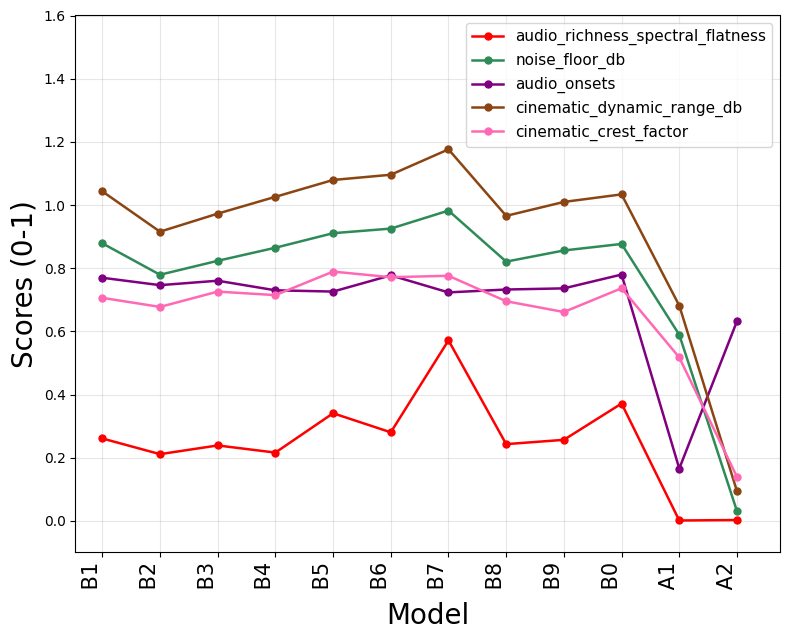

,ablation,audio_richness_spectral_flatness,audio_richness_spectral_entropy,noise_floor_db,audio_onsets,yt_coverage_score,yt_sync_score,yt_coverage_and_sync_coverage_score,yt_coverage_and_sync_sync_score,cinematic_dynamic_range_db,cinematic_spectral_flatness,cinematic_crest_factor,cinematic_spectral_entropy,cinematic_spectral_centroid_hz
0,decide_model_gemini-2.5-flash,0.026091,4.391861,-43.938738,76.972222,20.489518,2.362559e-03,20.489518,1.431172e-04,104.328822,0.026091,10.592178,4.391861,2029.809529
1,toggle_fill_coverage_by_llm,0.021126,4.424067,-38.962612,74.628571,21.182643,8.995143e-13,21.182643,5.627143e-14,91.562813,0.021126,10.161045,4.424067,2035.072704
2,toggle_use_avg_llm_and_dsp_to_predict_align,0.023885,4.401240,-41.169139,76.034483,23.371648,2.801690e-14,23.371648,1.751034e-15,97.273746,0.023885,10.887974,4.401240,2087.089447
3,toggle_use_dl_based_llm_and_dsp_alignment_pred...,0.021619,4.417654,-43.238796,73.000000,19.571827,1.657825e-03,19.571827,1.036141e-04,102.598148,0.021619,10.721402,4.417654,2071.790744
4,toggle_use_dsp,0.034076,4.442403,-45.540192,72.600000,22.343744,2.304147e-04,22.343744,1.440092e-05,107.930672,0.034076,11.837782,4.442403,2039.780873
5,toggle_use_dsp_to_predict_align,0.028041,4.471559,-46.267402,77.733333,19.833454,2.148261e-03,19.833454,1.342663e-04,109.583860,0.028041,11.572652,4.471559,2066.303657
6,toggle_use_llm_to_predict_align,0.057154,4.552328,-49.117593,72.333333,21.869168,1.096491e-04,21.869168,6.853070e-06,117.622796,0.057154,11.638761,4.552328,1917.270506
7,toggle_use_movie_bgms,0.024297,4.480536,-41.039687,73.250000,17.352656,6.156250e-33,17.352656,3.843750e-34,96.568657,0.024297,10.429744,4.480536,1997.478402
8,toggle_use_narrator,0.025663,4.278822,-42.805309,73.612903,19.955314,8.488964e-04,19.955314,5.305603e-05,100.978692,0.025663,9.919276,4.278822,2062.135553
9,BackgroundMellow_baseline,0.037154,4.436764,-43.838555,77.987179,23.634606,5.455483e-03,23.634606,3.179872e-04,103.368149,0.037154,11.048259,4.436764,2063.629042


In [92]:
# Ablation overlay from CSV — self-contained (edit variables only; no visualize_results helpers)

import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- paths & mode: raw vs pre-scaled export ---
CSV_PATH = "Results/final_ablations_results.csv"
# CSV_PATH = "Results/final_ablations_results_scaled.csv"
VALUES_ALREADY_SCALED = False  # True when using *_scaled.csv (skip SCALE_FACTORS)



# clap_score,
# audio_richness_spectral_flatness,
# audio_richness_spectral_entropy,
# noise_floor_db,
# audio_onsets,
# yt_coverage_score,yt_sync_score,
# yt_coverage_and_sync_coverage_score,
# yt_coverage_and_sync_sync_score,
# cinematic_dynamic_range_db,
# cinematic_crest_factor,
# cinematic_spectral_flatness,
# cinematic_spectral_entropy,
# cinematic_spectral_centroid_hz,

ABLATION_COL = "ablation"
METRICS = [
    "audio_richness_spectral_flatness",
    # # "audio_richness_spectral_entropy",
    "noise_floor_db",
    "audio_onsets",
    "cinematic_dynamic_range_db",
    "cinematic_crest_factor",
    # "cinematic_spectral_flatness",
    # "cinematic_spectral_entropy",
    # "cinematic_spectral_centroid_hz"  
    # "yt_coverage_score",
    # "yt_sync_score",  
    
]  # None = every column except ABLATION_COL; or e.g. ["noise_floor_db", "clap_score"]

# --- per-metric scale (same defaults as plot_ablation_metrics_overlay); unused if VALUES_ALREADY_SCALED ---
SCALE_FACTORS = {
    "total_seconds": 1.0 / 200.0,
    "clap_score": 1.0,
    "audio_richness_spectral_flatness": 10.0,
    "audio_richness_spectral_entropy": 1.0 / 10.0,
    "noise_floor_db": -1.0 / 50.0,
    "audio_onsets": 1.0 / 100.0,
    "cinematic_dynamic_range_db": 1.0 / 100.0,
    "cinematic_crest_factor": 1.0 / 15.0,
    "cinematic_spectral_flatness": 20.0,
    "cinematic_spectral_entropy": 1.0 / 200.0,
    "cinematic_spectral_centroid_hz": 1.0 / 3000.0,
    "yt_coverage_score": 1.0/30,
    "yt_sync_score": 200,
}

# --- one color per metric line ---
COLORS = {
    "clap_score": "black",
    "audio_richness_spectral_flatness": "red",
    "audio_richness_spectral_entropy": "darkorange",
    "total_seconds": "steelblue",
    "noise_floor_db": "seagreen",
    "audio_onsets": "purple",
    "cinematic_dynamic_range_db": "saddlebrown",
    "cinematic_crest_factor": "hotpink",
    "cinematic_spectral_flatness": "crimson",
    "cinematic_spectral_entropy": "goldenrod",
    "cinematic_spectral_centroid_hz": "navy",
    "yt_coverage_score": "crimson",
    "yt_sync_score": "blue",
}

# --- Custom ablation naming (keys must match the CSV `ablation` column exactly) ---
#
# ABLATION_AXIS_LABELS — text drawn under each x tick (your “paper names” on the graph).
# Leave empty {} to use abbreviation / raw tag (see USE_MIDDLE_ABBREV_FOR_UNMAPPED).
ABLATION_AXIS_LABELS = {
    "decide_model_gemini-2.5-flash":" B1",
    "toggle_fill_coverage_by_llm":" B2",
    "toggle_use_avg_llm_and_dsp_to_predict_align":" B3",   
    "toggle_use_dl_based_llm_and_dsp_alignment_predictor":" B4",
    "toggle_use_dsp":" B5",
    "toggle_use_dsp_to_predict_align":" B6",
    "toggle_use_llm_to_predict_align":" B7",
    "toggle_use_movie_bgms":" B8",
    "toggle_use_narrator":" B9",
    "BackgroundMellow_baseline":" B0",
    "AudioLDM2":" A1",
    "tango2":" A2"
}

# Optional: LEFT column of the side table (before "→"). Defaults to the axis label for that row.
ABLATION_KEY_LEFT_LABELS = {
   "decide_model_gemini-2.5":"DM_Gemini_2.5",
    "decide_model_gemini-2.5-flash":"Gemini_2.5",
    "toggle_fill_coverage_by_llm":"Fill_cues",
    "toggle_use_avg_llm_and_dsp_to_predict_align":"Avg_llm_dsp",   
    "toggle_use_dl_based_llm_and_dsp_alignment_predictor":"Dl_llm_dsp",
    "toggle_use_dsp":"Toggle_Dsp",
    "toggle_use_dsp_to_predict_align":"Dsp_only",
    "toggle_use_llm_to_predict_align":"Llm_only",
    "toggle_use_movie_bgms":"Movie_bgms",
    "toggle_use_narrator":"Narrator",
    "BackgroundMellow_baseline":"BMBaseline",
    "AudioLDM2":"AudioLDM2",
    "tango2":"Tango2"

}

# RIGHT column of the side table — human-readable explanation (like your toggle↔sentence mapping).
# If missing for a row, the raw CSV tag is shown on the right (same as old behavior).
ABLATION_KEY_RIGHT_DESCRIPTIONS = {
   "decide_model_gemini-2.5-flash":"Audio Deciding model : Gemini 2.5",
    "toggle_fill_coverage_by_llm":"Fill missing Cues with LLM",
    "toggle_use_avg_llm_and_dsp_to_predict_align":"Align with avg of LLM and DSP",   
    "toggle_use_dl_based_llm_and_dsp_alignment_predictor":"Align with DL based LLM and DSP",
    "toggle_use_dsp":"Use Alignment Predictor",
    "toggle_use_dsp_to_predict_align":"Align with DSP Only",
    "toggle_use_llm_to_predict_align":"Align with LLM Only",
    "toggle_use_movie_bgms":"Insert Movie BGMs",
    "toggle_use_narrator":"Use Narrator or Not",
    "BackgroundMellow_baseline":"Background Mellow baseline",
    "AudioLDM2":"AudioLDM2",
    "tango2":"Tango2"
}

# Metric curve names in the legend (CSV column name → display text).
METRIC_LEGEND_LABELS = {
    # "noise_floor_db": "Noise floor (dB)",
    # "cinematic_dynamic_range_db": "Dynamic range (dB)",
}


def _abbrev_middle(s: str, head: int = 4, tail: int = 3) -> str:
    t = str(s)
    if len(t) <= head + tail:
        return t
    return f"{t[:head]}…{t[-tail:]}"


USE_MIDDLE_ABBREV_FOR_UNMAPPED = True
SHORT_LABEL_HEAD = 4
SHORT_LABEL_TAIL = 3

XLABEL = "Model"
YLABEL = "Scores (0-1)"
TITLE = ""

# "two_column_key_below_legend" | "two_column_key_only" | "one_column_legend_outside" | "one_column_legend_inside"
LAYOUT = "one_column_legend_inside"
SHOW_ABLATION_KEY = True
KEY_PANEL_WIDTH_IN = 4
KEY_CHARS_PER_LINE = 52
KEY_FONT_SIZE = 10.0
KEY_TEXT_XY = (0.0, 1.0)
KEY_TEXT_VA = "top"
KEY_TEXT_HA = "left"

LEGEND_FONT_SIZE = 11
LEGEND_LOC = "upper left"
LEGEND_BBOX_TO_ANCHOR = None

TICK_ROTATION = 90
TICK_FONT_SIZE = 15
FIGSIZE = None


# Set YLIM to a tuple, e.g., (0, 0.8), to set the y-axis upper limit
YLIM = (-0.1,1.6)  # e.g., (0, 0.8). None means default/matplotlib auto.

# X_AXIS_LABEL_EXTRA (fraction of one step to leave empty after all x labels)
X_AXIS_LABEL_EXTRA = 0.8  # increase this (e.g. 1.0) for more space at right of x-axis



DPI = 200
SAVE_FIG_PATH = Path("Results/plots/ablation_metrics_from_csv.png")

# ---------- load ----------
tab = pd.read_csv(CSV_PATH, low_memory=False)
if ABLATION_COL not in tab.columns:
    raise KeyError(f"missing column {ABLATION_COL!r}")
metric_cols = list(METRICS) if METRICS else [c for c in tab.columns if c != ABLATION_COL]
tab = tab.drop_duplicates(subset=[ABLATION_COL], keep="first")

labels_full = tab[ABLATION_COL].astype(str).tolist()
tick_labels = []
for lb in labels_full:
    if lb in ABLATION_AXIS_LABELS:
        tick_labels.append(ABLATION_AXIS_LABELS[lb])
    elif USE_MIDDLE_ABBREV_FOR_UNMAPPED:
        tick_labels.append(_abbrev_middle(lb, SHORT_LABEL_HEAD, SHORT_LABEL_TAIL))
    else:
        tick_labels.append(lb)

n = len(tab)
if n == 0:
    raise ValueError("CSV has no rows")

# --------- Compute custom x-array with additional space at right ----------
# Add extra space at end of x axis for labels/legend according to user param:
x = np.arange(n, dtype=float)
if X_AXIS_LABEL_EXTRA and X_AXIS_LABEL_EXTRA > 0:
    x_max = n - 1 + X_AXIS_LABEL_EXTRA
    x_display = np.linspace(0, x_max, n)
    ax_xticks = x_display
else:
    x_display = x
    ax_xticks = x

lay = LAYOUT
if not SHOW_ABLATION_KEY and lay.startswith("two_column"):
    lay = "one_column_legend_outside"

w_main = max(8.0, 0.22 * n)
h = 6.5
use_two_col = SHOW_ABLATION_KEY and lay.startswith("two_column")
key_w = KEY_PANEL_WIDTH_IN if use_two_col else 0.0
fig = plt.figure(figsize=FIGSIZE or (w_main + key_w, h))

ax_key = None
ax_leg = None
if lay == "two_column_key_below_legend" and use_two_col:
    gs = fig.add_gridspec(
        2,
        2,
        width_ratios=[w_main, key_w],
        height_ratios=[7.5, 1.25],
        wspace=0.08,
        hspace=0.18,
    )
    ax = fig.add_subplot(gs[:, 0])
    ax_key = fig.add_subplot(gs[0, 1])
    ax_leg = fig.add_subplot(gs[1, 1])
    ax_key.axis("off")
    ax_leg.axis("off")
elif lay == "two_column_key_only" and use_two_col:
    gs = fig.add_gridspec(1, 3, width_ratios=[w_main, key_w], wspace=0.1)
    ax = fig.add_subplot(gs[0, 0])
    ax_key = fig.add_subplot(gs[0, 1])
    ax_key.axis("off")
else:
    ax = fig.add_subplot(1, 1, 1)

if ax_key is not None:
    key_lines = []
    for i in range(n):
        csv_tag = labels_full[i]
        left_k = ABLATION_KEY_LEFT_LABELS.get(csv_tag, tick_labels[i])
        right_k = ABLATION_KEY_RIGHT_DESCRIPTIONS.get(csv_tag, csv_tag)
        key_lines.append(textwrap.fill(f"{left_k} → {right_k}", width=KEY_CHARS_PER_LINE))

        
    key_body = "\n\n".join(key_lines)
    ax_key.text(
        KEY_TEXT_XY[0],
        KEY_TEXT_XY[1],
        key_body,
        transform=ax_key.transAxes,
        va=KEY_TEXT_VA,
        ha=KEY_TEXT_HA,
        fontsize=KEY_FONT_SIZE,
        family="monospace",
    )

fallback = plt.cm.tab10(np.linspace(0, 0.9, max(10, len(metric_cols))))

for mi, m in enumerate(metric_cols):
    if m not in tab.columns:
        continue
    y = tab[m].to_numpy(dtype=float)
    if not VALUES_ALREADY_SCALED:
        y = y * float(SCALE_FACTORS.get(m, 1.0))
    c = COLORS.get(m, fallback[mi % len(fallback)])
    leg = METRIC_LEGEND_LABELS.get(m, m)
    ax.plot(x_display, y, "o-", color=c, linewidth=1.8, markersize=5, label=leg)

ax.set_xticks(ax_xticks)
ax.set_xticklabels(tick_labels, rotation=TICK_ROTATION, ha="right", fontsize=TICK_FONT_SIZE)
ax.set_xlabel(XLABEL, fontsize=20)
ax.set_ylabel(YLABEL, fontsize=20)
ax.set_title(TITLE, fontsize=20)
if YLIM is not None:
    ax.set_ylim(YLIM)
ax.grid(True, alpha=0.3)

# Optionally stretch x lim so there's always space at right for legend even for long x labels:
if X_AXIS_LABEL_EXTRA and X_AXIS_LABEL_EXTRA > 0:
    ax.set_xlim(left=x_display[0] - 0.5, right=x_display[-1] + X_AXIS_LABEL_EXTRA)

handles, labels_for_leg = ax.get_legend_handles_labels()
bbox = LEGEND_BBOX_TO_ANCHOR
if lay == "two_column_key_below_legend" and ax_leg is not None:
    ax_leg.legend(
        handles,
        labels_for_leg,
        loc=LEGEND_LOC,
        bbox_to_anchor=bbox if bbox is not None else (0.0, 1.0),
        fontsize=LEGEND_FONT_SIZE,
        frameon=True,
        borderaxespad=0.0,
    )
elif lay in ("two_column_key_only", "one_column_legend_outside"):
    ax.legend(
        handles,
        labels_for_leg,
        loc=LEGEND_LOC,
        bbox_to_anchor=bbox if bbox is not None else (1.02, 1.0),
        fontsize=LEGEND_FONT_SIZE,
        frameon=True,
    )
else:
    ax.legend(
        handles, labels_for_leg, loc="upper right", fontsize=LEGEND_FONT_SIZE, frameon=True,
        
    )

fig.tight_layout()
SAVE_FIG_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(SAVE_FIG_PATH, dpi=DPI, bbox_inches="tight")
plt.show()

tab
